# FMUCD Exploratory Data Analysis
This notebook explores the Facility Management Unified Classification Database (FMUCD) to understand:
- Planned vs Unplanned maintenance patterns
- System-level risk and cost drivers
- Seasonal and weather effects
- Opportunities for predictive modeling


In [13]:
import pandas as pd
import numpy as np
from scipy import stats

# 1) Load
path = "/Users/mehakxoxo/Documents/spring_2026/data_practicum/Facility Management Unified Classification Database (FMUCD)/Facility Management Unified Classification Database (FMUCD).csv"
df = pd.read_csv(path)

df.columns = df.columns.str.strip()

print("Shape:", df.shape)
display(df.head(10))

/var/folders/29/flsbf9x54_s07dtd6_r_mrvm0000gn/T/ipykernel_36618/4276206651.py:7: DtypeWarning: Columns (3,4,6,10,17,19,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Shape: (3731442, 38)


,UniversityID,Country,State/Province,BuildingID,BuildingName,Size,Type,BuiltYear,FCI (facility condition index),CRV (current replacement value),...,LaborHours,MinTemp.(°C),MaxTemp.(°C),Atmospheric pressure(hPa),Humidity(%),WindSpeed(m/s),WindDegree,Precipitation(mm),Snow(mm),Cloudness(%)
0,1,Canada,Nova Scotia,A050,COBURG ROAD 6414,5529.0,Research,1942.0,0.786664,981590.0,...,3.0,-4.232917,0.299583,1023.291667,82.541667,2.379167,170.583333,0.00,0.00,87.583333
1,1,Canada,Nova Scotia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,-6.034583,-0.784167,998.125000,75.625000,4.229167,278.541667,0.00,0.11,77.500000
2,1,Canada,Nova Scotia,C201,LSC-BIOL&EARTH,161395.0,Mixed Teaching/Research,1971.0,0.449394,52886380.0,...,0.0,-9.900417,-1.926667,1017.250000,84.208333,1.924167,254.833333,0.00,4.42,88.375000
3,1,Canada,Nova Scotia,J351,SEXTON MEMORIAL GYM,30619.0,Student Experience,1963.0,0.692297,6394240.0,...,19.5,5.243750,6.841667,1014.375000,98.041667,3.924583,225.833333,0.00,0.00,82.958333
4,1,Canada,Nova Scotia,C201,LSC-BIOL&EARTH,161395.0,Mixed Teaching/Research,1971.0,0.449394,52886380.0,...,0.5,0.602500,4.664167,1012.833333,91.500000,3.895417,176.791667,2.39,1.16,81.000000
5,1,Canada,Nova Scotia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,52.0,-17.141667,-11.976667,1006.833333,63.083333,4.737500,257.916667,0.00,0.00,62.791667
6,1,Canada,Nova Scotia,J920,MORRIS 5247,4405.0,Research,1850.0,0.030819,874470.0,...,0.5,-12.908333,-7.115000,1019.416667,64.666667,4.153750,305.625000,0.00,0.00,23.083333
7,1,Canada,Nova Scotia,C202,LSC-OCEANOGRAPH,107080.0,Mixed Teaching/Research,1971.0,0.561959,29240670.0,...,1.0,-12.090417,-5.960417,1013.208333,62.000000,4.212500,238.750000,0.00,0.00,46.541667
8,1,Canada,Nova Scotia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.5,-1.270833,2.135000,1026.666667,77.541667,2.762500,113.833333,0.00,0.00,74.916667
9,1,Canada,Nova Scotia,E100,STUD. UNION BLDG,124378.0,Student Experience,1967.0,0.481091,27171400.0,...,2.0,-0.876667,1.931667,994.375000,77.125000,5.833333,291.666667,0.00,13.45,69.875000


In [14]:
df.columns

Index(['UniversityID', 'Country', 'State/Province', 'BuildingID',
       'BuildingName', 'Size', 'Type', 'BuiltYear',
       'FCI (facility condition index)', 'CRV (current replacement value)',
       'DMC (deferred maintenance cost)', 'SystemCode', 'SystemDescription',
       'SubsystemCode', 'SubsystemDescription', 'DescriptiveCode',
       'ComponentDescription', 'WOID', 'WODescription', 'WOPriority',
       'WOStartDate', 'WOEndDate', 'WODuration', 'PPM/UPM', 'LaborCost',
       'MaterialCost', 'OtherCost', 'TotalCost', 'LaborHours', 'MinTemp.(°C)',
       'MaxTemp.(°C)', 'Atmospheric pressure(hPa)', 'Humidity(%)',
       'WindSpeed(m/s)', 'WindDegree', 'Precipitation(mm)', 'Snow(mm)',
       'Cloudness(%)'],
      dtype='object')

In [15]:
df.shape

(3731442, 38)

In [16]:
df.dtypes

UniversityID                         int64
Country                             object
State/Province                      object
BuildingID                          object
BuildingName                        object
Size                               float64
Type                                object
BuiltYear                          float64
FCI (facility condition index)     float64
CRV (current replacement value)    float64
DMC (deferred maintenance cost)     object
SystemCode                          object
SystemDescription                   object
SubsystemCode                       object
SubsystemDescription                object
DescriptiveCode                     object
ComponentDescription                object
WOID                                object
WODescription                       object
WOPriority                          object
WOStartDate                         object
WOEndDate                           object
WODuration                         float64
PPM/UPM    

In [17]:

df['PPM/UPM'].value_counts(normalize=True)


PPM/UPM
PPM    0.602259
UPM    0.397741
Name: proportion, dtype: float64

In [18]:
print(df.columns.tolist())



['UniversityID', 'Country', 'State/Province', 'BuildingID', 'BuildingName', 'Size', 'Type', 'BuiltYear', 'FCI (facility condition index)', 'CRV (current replacement value)', 'DMC (deferred maintenance cost)', 'SystemCode', 'SystemDescription', 'SubsystemCode', 'SubsystemDescription', 'DescriptiveCode', 'ComponentDescription', 'WOID', 'WODescription', 'WOPriority', 'WOStartDate', 'WOEndDate', 'WODuration', 'PPM/UPM', 'LaborCost', 'MaterialCost', 'OtherCost', 'TotalCost', 'LaborHours', 'MinTemp.(°C)', 'MaxTemp.(°C)', 'Atmospheric pressure(hPa)', 'Humidity(%)', 'WindSpeed(m/s)', 'WindDegree', 'Precipitation(mm)', 'Snow(mm)', 'Cloudness(%)']


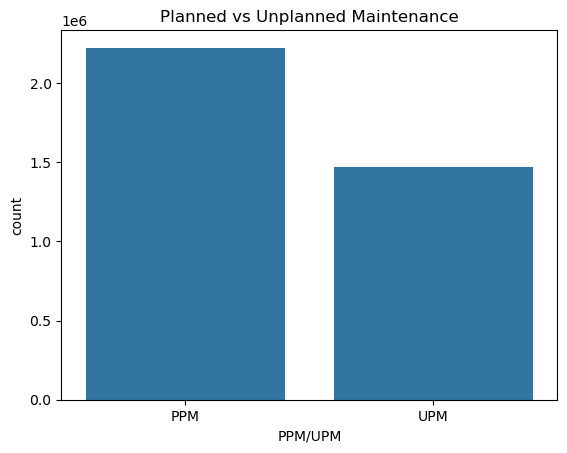

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='PPM/UPM')
plt.title("Planned vs Unplanned Maintenance")
plt.show()


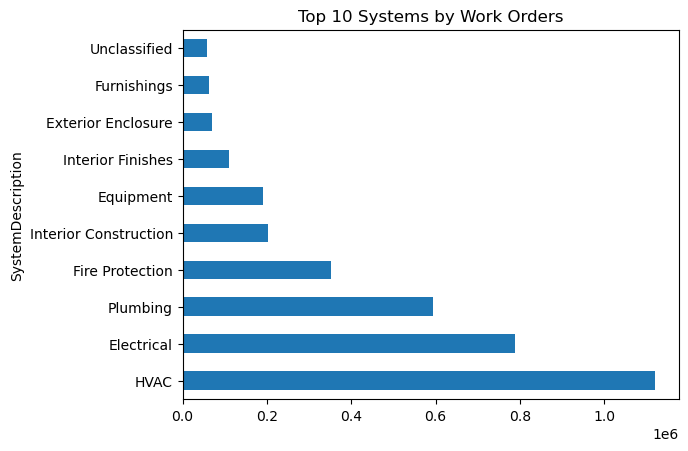

In [20]:
top_systems = df['SystemDescription'].value_counts().head(10)
top_systems.plot(kind='barh', title='Top 10 Systems by Work Orders')
plt.show()


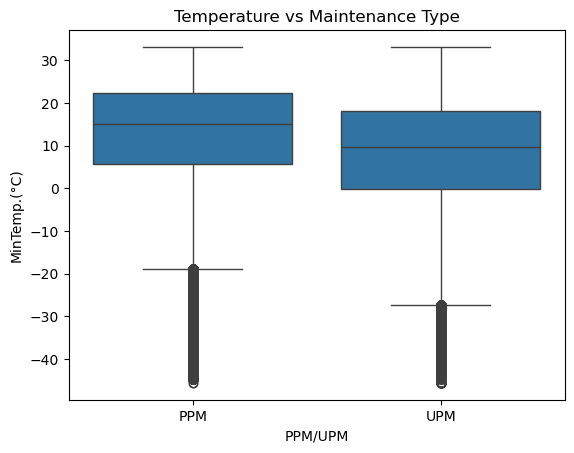

In [21]:
sns.boxplot(data=df, x='PPM/UPM', y='MinTemp.(°C)')
plt.title("Temperature vs Maintenance Type")
plt.show()


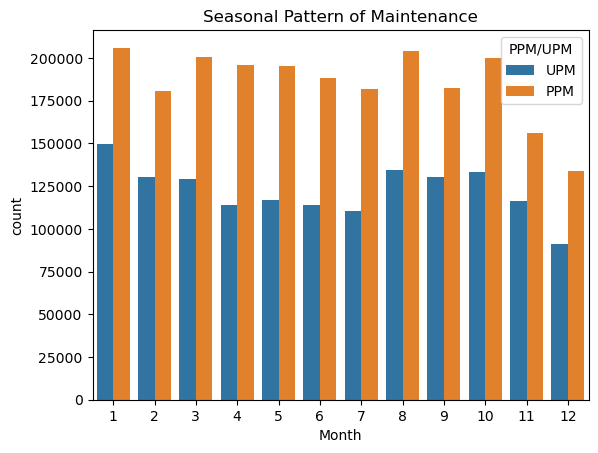

In [22]:
df['WOStartDate'] = pd.to_datetime(df['WOStartDate'], format='mixed', errors='coerce')
df['Month'] = df['WOStartDate'].dt.month

sns.countplot(x='Month', hue='PPM/UPM', data=df)
plt.title("Seasonal Pattern of Maintenance")
plt.show()


In [23]:
df.groupby('SystemDescription')['LaborCost'].mean().sort_values(ascending=False).head(10)


SystemDescription
Site Improvements                   1262.030051
Selective Building Demolition \n    1011.950309
Unclassified                         666.843205
Foundations                          626.933765
General                              542.596864
Stairs                               430.514557
Interior Finishes                    403.018530
Roofing                              331.075040
Site Mechanical Utilities            289.104339
Superstructure                       254.781592
Name: LaborCost, dtype: float64

In [24]:
df.groupby('SystemDescription')['Target_UPM'].mean().sort_values(ascending=False).head(10)


KeyError: 'Column not found: Target_UPM'

### Key Findings
1. HVAC, Electrical, and Plumbing dominate work orders.
2. Interior Construction and Site Improvements show highest UPM rates.
3. UPM costs show higher variance than PPM.
4. Winter months show increased emergency activity.
5. Low temperature correlates with higher UPM probability.
6. Certain systems consistently exhibit high failure risk.

